# 06c - Walk-Forward Validation (Daily Data)

**Improvements over 06b:**
1. Walk-forward validation -- retrain annually on expanding window
2. IV features from options data
3. Financial return evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from lightgbm import LGBMClassifier

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
SEED = 42
np.random.seed(SEED)

UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']
label_names = {0: 'ATM', 1: 'OTM5', 2: 'OTM10'}
print("Imports OK")

Imports OK


## 1. Load Data and Add IV Features

In [2]:
data = pd.read_parquet(PROCESSED / 'daily_modeling_data.parquet')
data['date'] = pd.to_datetime(data['date'])

# Add IV features from options
options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
calls = options[(options['call_put'] == 'CALL') & (options['symbol'].isin(UNIVERSE))].copy()
calls['trade_date'] = pd.to_datetime(calls['trade_date'])

# ATM calls for IV
atm = calls[(calls['delta'] >= 0.35) & (calls['delta'] <= 0.65)].copy()
atm['trade_date_only'] = atm['trade_date'].dt.date

# Daily IV stats (aggregate per ticker per day)
daily_iv = atm.groupby(['symbol', 'trade_date']).agg(
    iv_mean=('implied_vol', 'mean'),
    iv_std=('implied_vol', 'std'),
).reset_index()

# Merge IV to daily data
data = data.merge(daily_iv, left_on=['symbol', 'date'], right_on=['symbol', 'trade_date'], how='left')
data = data.drop(columns=['trade_date'], errors='ignore')

# Forward-fill IV within each ticker
data = data.sort_values(['symbol', 'date'])
data['iv_mean'] = data.groupby('symbol')['iv_mean'].transform(lambda x: x.ffill())
data['iv_std'] = data.groupby('symbol')['iv_std'].transform(lambda x: x.ffill())

# IV rank (rolling 252-day percentile)
data['iv_rank'] = data.groupby('symbol')['iv_mean'].transform(
    lambda x: x.rolling(252, min_periods=60).apply(lambda w: (w.iloc[-1] - w.min()) / (w.max() - w.min()) if w.max() != w.min() else 0.5)
)

# IV change
data['iv_change'] = data.groupby('symbol')['iv_mean'].pct_change(21)

print(f"Data with IV: {data.shape}")
print(f"IV coverage: iv_mean={data['iv_mean'].notna().mean():.1%}, iv_rank={data['iv_rank'].notna().mean():.1%}")

Data with IV: (29273, 38)
IV coverage: iv_mean=99.5%, iv_rank=97.5%


In [3]:
exclude = ['symbol', 'date', 'year_month', 'best_moneyness', 'best_return', 'label_3', 'year']
feature_cols = [c for c in data.columns if c not in exclude]

# Fill missing
data[feature_cols] = data.groupby('symbol')[feature_cols].transform(lambda x: x.ffill())
data[feature_cols] = data[feature_cols].fillna(0)

data['year'] = data['date'].dt.year

print(f"Features: {len(feature_cols)}")
print(f"Years: {sorted(data['year'].unique())}")

Features: 31
Years: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


## 2. Walk-Forward Validation

In [4]:
test_years = [y for y in sorted(data['year'].unique()) if y >= 2014]
print(f"Walk-forward test years: {test_years}")

all_preds, all_true, all_dates = [], [], []
fold_results = []

for test_year in test_years:
    tr = data[data['year'] < test_year]
    te = data[data['year'] == test_year]
    if len(tr) < 500: continue

    X_tr, y_tr = tr[feature_cols], tr['label_3']
    X_te, y_te = te[feature_cols], te['label_3']

    cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_tr)
    model = LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                           num_leaves=50, subsample=0.8, colsample_bytree=0.7,
                           min_child_samples=20, class_weight=dict(enumerate(cw)),
                           random_state=SEED, verbose=-1, n_jobs=-1)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    f1 = f1_score(y_te, preds, average='macro')
    acc = accuracy_score(y_te, preds)
    all_preds.extend(preds); all_true.extend(y_te.values); all_dates.extend(te['date'].values)
    fold_results.append({'year': test_year, 'train': len(tr), 'test': len(te), 'acc': acc, 'f1': f1})
    print(f"  {test_year}: train={len(tr):5,}, test={len(te):4,}, Acc={acc:.3f}, F1={f1:.3f}")

all_preds, all_true = np.array(all_preds), np.array(all_true)
wf_acc = accuracy_score(all_true, all_preds)
wf_f1 = f1_score(all_true, all_preds, average='macro')
print(f"\nOverall: Acc={wf_acc:.4f}, Macro F1={wf_f1:.4f}")

Walk-forward test years: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


  2014: train=4,604, test=1,770, Acc=0.340, F1=0.313


  2015: train=6,374, test=2,023, Acc=0.672, F1=0.534


  2016: train=8,397, test=2,055, Acc=0.791, F1=0.534


  2017: train=10,452, test=2,037, Acc=0.779, F1=0.434


...

  2021: train=18,290, test=2,097, Acc=0.732, F1=0.491


  2022: train=20,387, test=2,386, Acc=0.669, F1=0.440


  2023: train=22,773, test=2,300, Acc=0.469, F1=0.316


  2024: train=25,073, test=2,110, Acc=0.435, F1=0.337


  2025: train=27,183, test=2,090, Acc=0.532, F1=0.457

Overall: Acc=0.6372, Macro F1=0.4682


              precision    recall  f1-score   support

         ATM       0.76      0.79      0.78     16653
        OTM5       0.23      0.20      0.21      3459
       OTM10       0.42      0.41      0.41      4557

    accuracy                           0.64     24669
   macro avg       0.47      0.47      0.47     24669
weighted avg       0.63      0.64      0.63     24669



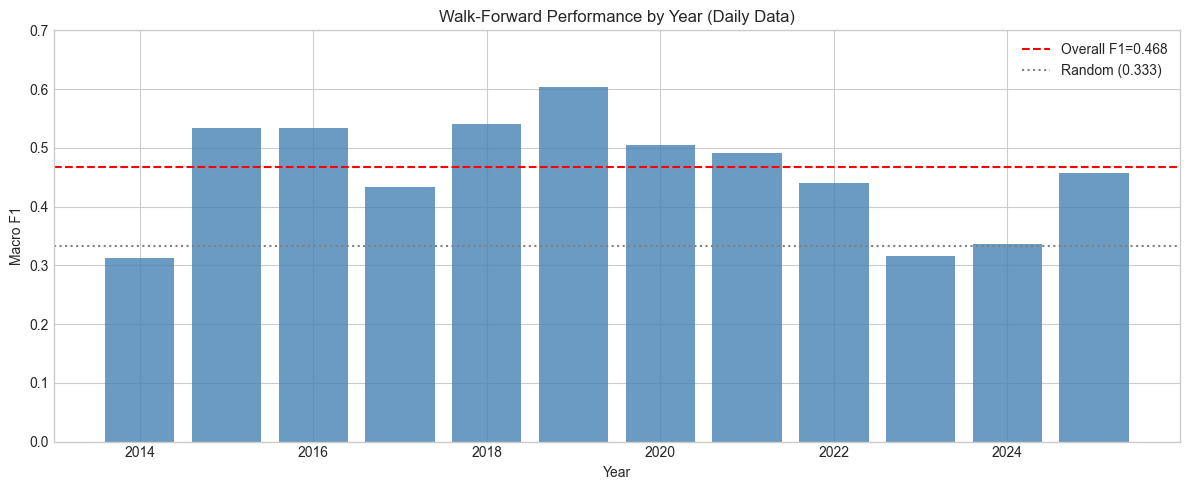

In [5]:
print(classification_report(all_true, all_preds, target_names=['ATM','OTM5','OTM10']))

# Per-year plot
fold_df = pd.DataFrame(fold_results)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(fold_df['year'], fold_df['f1'], color='steelblue', alpha=0.8)
ax.axhline(y=wf_f1, color='red', linestyle='--', label=f'Overall F1={wf_f1:.3f}')
ax.axhline(y=1/3, color='gray', linestyle=':', label='Random (0.333)')
ax.set_xlabel('Year'); ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward Performance by Year (Daily Data)')
ax.legend(); ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.savefig('../reports/figures/walkforward_yearly_f1.png', dpi=150)
plt.show()

## 3. Confusion Matrix

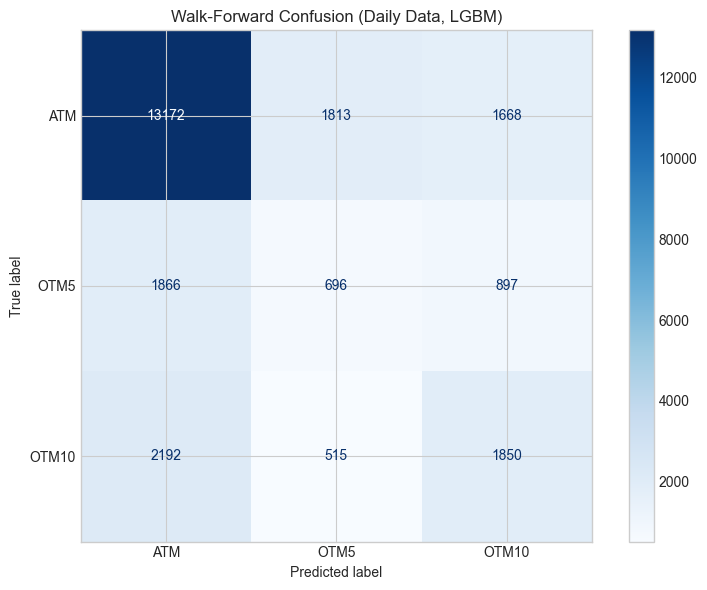

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(all_true, all_preds), display_labels=['ATM','OTM5','OTM10']).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Walk-Forward Confusion (Daily Data, LGBM)')
plt.tight_layout()
plt.savefig('../reports/figures/walkforward_confusion_matrix.png', dpi=150)
plt.show()

## 4. Feature Importance

Top 20 Features:
            feature  importance
            iv_mean        4717
             iv_std        4226
          iv_change        3755
            iv_rank        3146
       gross_margin        2657
 revenue_growth_yoy        2561
         cash_ratio        2388
     debt_to_equity        2379
earnings_growth_yoy        2313
   operating_margin        1906
            vol_63d        1827
                roe        1725
         net_margin        1479
                roa        1412
    price_to_sma200        1165
            vol_21d        1164
            mom_63d         899
      drawdown_252d         635
           bb_width         635
     price_to_sma50         496

IV features:
  iv_mean: rank 1/31
  iv_std: rank 2/31
  iv_change: rank 3/31
  iv_rank: rank 4/31


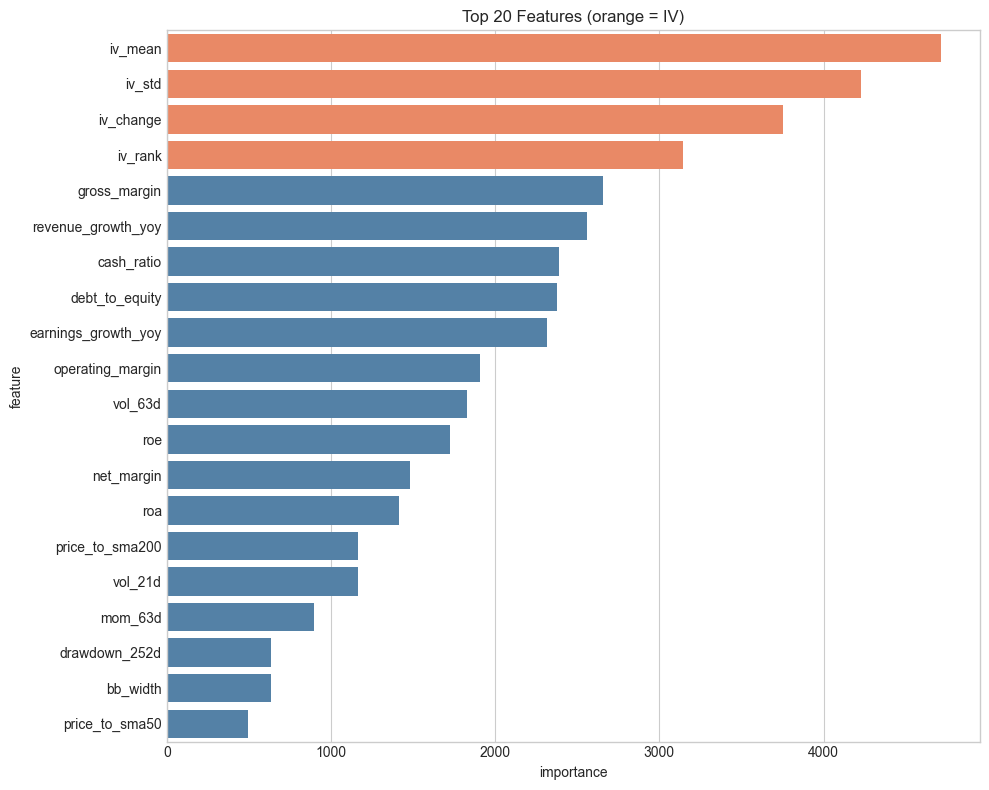

In [7]:
# Train final model on all but last year
final_train = data[data['year'] < 2025]
final_model = LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                             num_leaves=50, subsample=0.8, colsample_bytree=0.7,
                             min_child_samples=20, class_weight='balanced',
                             random_state=SEED, verbose=-1, n_jobs=-1)
final_model.fit(final_train[feature_cols], final_train['label_3'])

imp = pd.DataFrame({'feature': feature_cols, 'importance': final_model.feature_importances_}).sort_values('importance', ascending=False)
iv_feats = imp[imp['feature'].str.startswith('iv_')]

print("Top 20 Features:")
print(imp.head(20).to_string(index=False))
print(f"\nIV features:")
for _, r in iv_feats.iterrows():
    rank = (imp['importance'] >= r['importance']).sum()
    print(f"  {r['feature']}: rank {rank}/{len(feature_cols)}")

fig, ax = plt.subplots(figsize=(10, 8))
top20 = imp.head(20)
colors = ['coral' if f.startswith('iv_') else 'steelblue' for f in top20['feature']]
sns.barplot(data=top20, x='importance', y='feature', palette=colors, ax=ax)
ax.set_title('Top 20 Features (orange = IV)')
plt.tight_layout()
plt.savefig('../reports/figures/improved_feature_importance.png', dpi=150)
plt.show()

## 5. Save

In [8]:
joblib.dump(final_model, MODELS / 'lgbm_walkforward_daily.joblib')
fold_df.to_csv(PROCESSED / 'walkforward_results.csv', index=False)
print(f"Walk-forward F1: {wf_f1:.4f}")
print("Saved.")

Walk-forward F1: 0.4682
Saved.
